# Exploratory Data Analysis (EDA) on Retail Sales Data
## Objective:
The objective of this project is to perform Exploratory Data Analysis (EDA) on a retail sales dataset
to identify patterns, trends, and insights that can help a retail business make informed decisions.

## Dataset Description
The dataset used in this project is a retail sales dataset obtained from Kaggle. It contains
information about sales transactions including date of purchase, product category, quantity sold,
price, total sales amount, and customer demographic details such as gender and age.

## Libraries Used
The following Python libraries are used for data analysis and visualization:
- Pandas for data manipulation
- NumPy for numerical operations
- Matplotlib and Seaborn for data visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading
The dataset is loaded into a Pandas DataFrame to allow easy data manipulation and analysis.
Initial inspection is performed to understand the structure and contents of the dataset.

In [2]:
df = pd.read_csv("retail_sales_dataset.csv")

In [3]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.shape

(1000, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


## Data Cleaning and Preprocessing
Data cleaning is an essential step in EDA to ensure accuracy and reliability of analysis.
This includes checking for missing values, removing duplicate records, and converting data
types where necessary.

In [6]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [7]:
df = df.drop_duplicates()

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df = df.sort_values('Date')

## Descriptive Statistics
Descriptive statistics are used to summarize the main characteristics of the dataset.
Key statistics such as mean, median, mode, and standard deviation help in understanding
sales distribution and variability.

In [10]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [11]:
# Mean
df.mean(numeric_only=True)

# Median
df.median(numeric_only=True)

# Mode
df.mode().iloc[0]

# Standard Deviation
df.std(numeric_only=True)

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

## Time Series Analysis
Time series analysis is performed to study sales trends over time. This helps in identifying
seasonal patterns, growth trends, and fluctuations in sales performance.

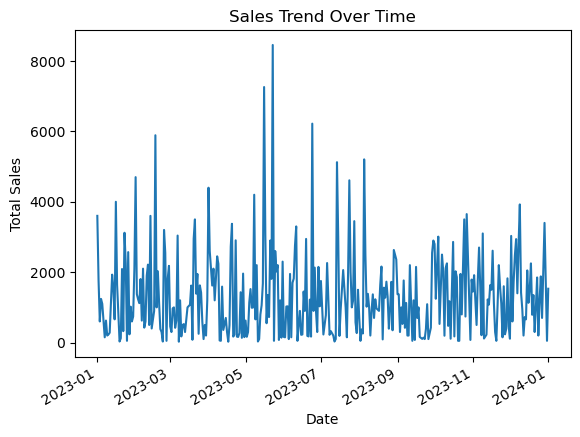

In [12]:
# Group sales by date
sales_over_time = df.groupby('Date')['Total Amount'].sum()

# Plot sales trend
plt.figure()
sales_over_time.plot()
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

Monthly Sales Trend Analysis

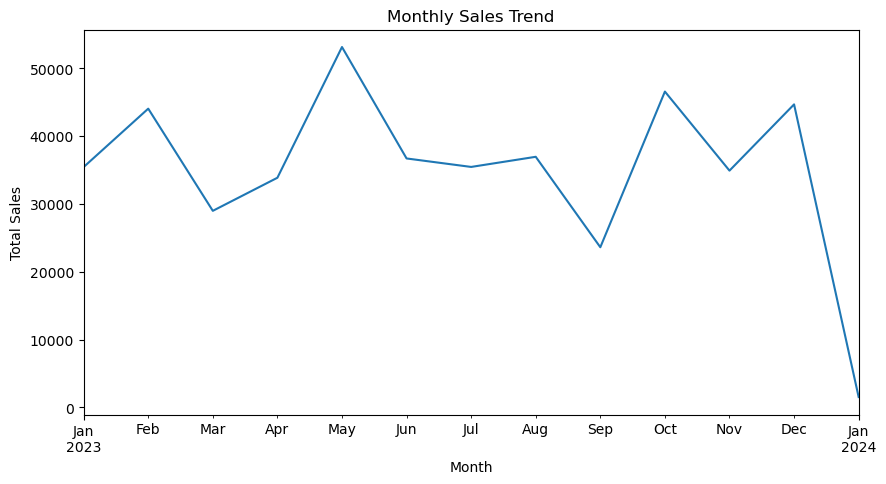

In [13]:
monthly_sales = df.resample('ME', on='Date')['Total Amount'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

## Customer Analysis
Customer analysis helps in understanding purchasing behavior based on demographic factors
such as gender, which can support targeted marketing strategies.

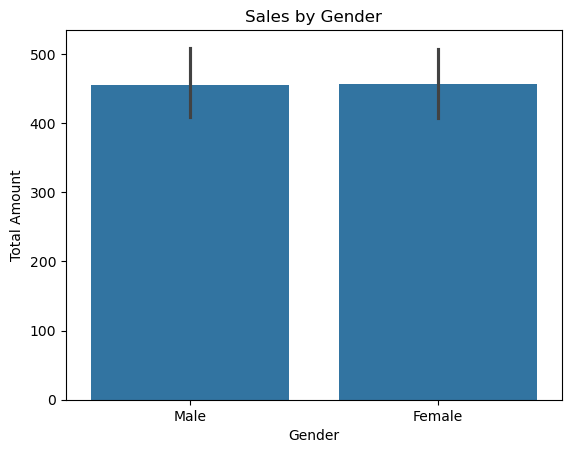

In [14]:
sns.barplot(x='Gender', y='Total Amount', data=df)
plt.title("Sales by Gender")
plt.show()

Age-based Customer Analysis

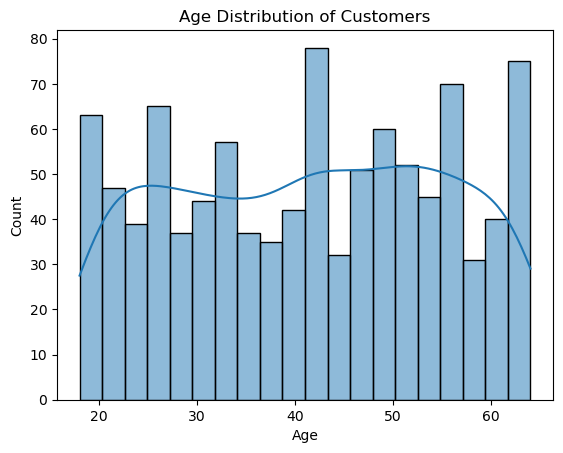

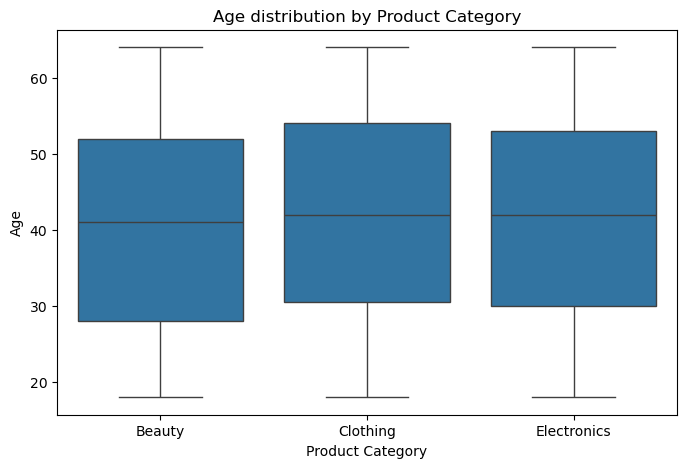

In [15]:
plt.figure()
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Age vs Product purchase behaviour
plt.figure(figsize=(8,5))
sns.boxplot(x='Product Category', y='Age', data=df)
plt.title("Age distribution by Product Category")
plt.show()

Top Customers by Spending

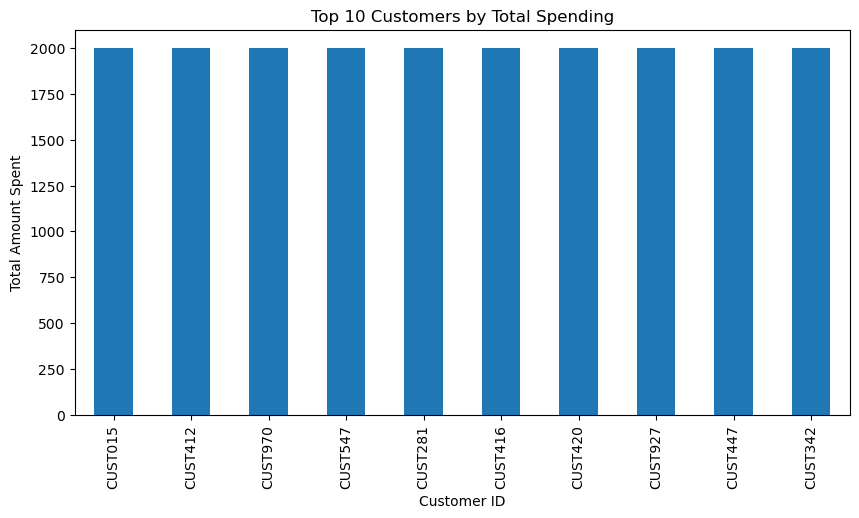

In [16]:
customer_spend = df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
customer_spend.plot(kind='bar')
plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Amount Spent")
plt.show()

## Product Analysis
Product analysis is performed to identify top-performing product categories and understand
their contribution to overall sales.

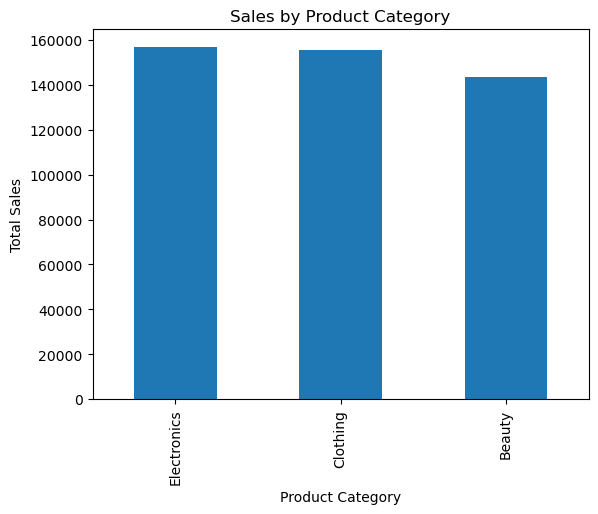

In [17]:
top_products = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

top_products.plot(kind='bar')
plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.show()

## Data Visualization
Visualizations such as bar charts, line plots, and heatmaps are used to present insights
in a clear and effective manner.

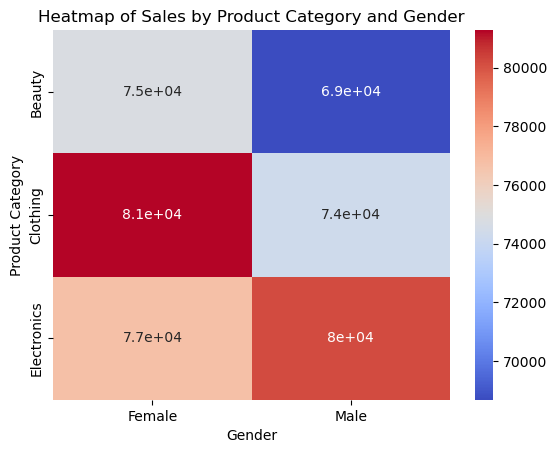

In [18]:
pivot_table = pd.pivot_table(df, values='Total Amount', index='Product Category', columns='Gender', aggfunc='sum')

sns.heatmap(pivot_table, annot=True, cmap='coolwarm')
plt.title("Heatmap of Sales by Product Category and Gender")
plt.show()

## Insights and Observations
- Sales show noticeable variation over time, indicating the presence of peak and low demand periods.
- Certain product categories contribute significantly more to total sales.
- Customer purchasing behavior differs based on gender.
- Some product categories perform consistently well across demographics.
- Time-based trends can help forecast future sales.

## Recommendations
- Focus inventory management on high-performing product categories.
- Plan promotional campaigns during peak sales periods.
- Use customer demographic insights to personalize marketing strategies.
- Monitor sales trends regularly to anticipate demand changes.

## Conclusion
This exploratory data analysis provided valuable insights into retail sales trends, customer
behavior, and product performance. The findings can help retail businesses improve decision-making,
optimize sales strategies, and enhance overall performance.